In [1]:
source('/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/MS0_Libraries.r')

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/miniconda3/envs/my_jupyter_env/lib/R/library/"


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘backports’ w

In [2]:
packageVersion("Seurat")

[1] ‘5.1.0’

In [2]:
seurat_obj = readRDS("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/seurat_integrated.Rds")

In [3]:
seurat_obj

Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘sp’


The following object is masked from ‘package:ggraph’:

    geometry



Attaching package: ‘SeuratObject’


The following object is masked from ‘package:backports’:

    %||%


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Seurat


Attaching package: ‘Seurat’


The following object is masked from ‘package:backports’:

    %||%




An object of class Seurat 
57394 features across 125269 samples within 3 assays 
Active assay: SCT (26795 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, HTO
 3 dimensional reductions calculated: pca, harmony, umap

In [5]:
head(seurat_obj)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,S.Score,G2M.Score,Phase,old.ident,nCount_HTO,nFeature_HTO,⋯,HTO_classification,HTO_classification.global,hash.ID,CSclassification,Patient,nCount_SCT,nFeature_SCT,SCT_snn_res.0.3,seurat_clusters,Idents
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<fct>,<fct>,<fct>
AAACCCAAGTTTGAGA-1_1,Pool1,795,294,0.1257862,-0.019962198,0.011491309,G2M,Pool1,712,10,⋯,HTO-B0259,Singlet,HTO-B0259,KS,KS35.2,933,294,0,0,T cells
AAACCCACACGGCCAT-1_1,Pool1,1144,494,0.7867133,0.024573726,-0.007187476,S,Pool1,824,10,⋯,HTO-B0253,Singlet,HTO-B0253,KS,KS32.1,1110,491,1,1,Regulatory T cells
AAACCCACACTCTAGA-1_1,Pool1,1929,854,0.0000000,-0.004932269,0.062951827,G2M,Pool1,1078,10,⋯,HTO-B0253,Singlet,HTO-B0253,KS,KS32.1,1398,835,3,3,Classical Monocytes
AAACCCAGTATCGATC-1_1,Pool1,999,366,1.0010010,-0.023320280,-0.029489366,G1,Pool1,540,10,⋯,HTO-B0258,Singlet,HTO-B0258,KS,KS35.1,1011,364,0,0,T cells
AAACCCAGTTCATCGA-1_1,Pool1,3731,1639,0.4824444,-0.045329681,-0.033604501,G1,Pool1,2077,10,⋯,HTO-B0253,Singlet,HTO-B0253,KS,KS32.1,1022,507,3,3,Classical Monocytes
AAACCCATCCTACAAG-1_1,Pool1,11360,3733,0.3080986,0.010721967,-0.044746772,S,Pool1,16182,10,⋯,HTO-B0258,Singlet,HTO-B0258,KS,KS35.1,1030,406,5,5,B Cells
AAACGAAAGACAGCGT-1_1,Pool1,639,397,0.1564945,0.017079740,0.003579214,S,Pool1,1016,10,⋯,HTO-B0259,Singlet,HTO-B0259,KS,KS35.2,834,398,2,2,NK cells
AAACGAAAGCAGCGAT-1_1,Pool1,1084,387,0.1845018,-0.016690002,-0.041334653,G1,Pool1,738,10,⋯,HTO-B0257,Singlet,HTO-B0257,KS,KS4.2,1083,387,0,0,T cells
AAACGAAAGCTAGTTC-1_1,Pool1,4432,1931,1.2635379,-0.008198070,-0.103716891,G1,Pool1,4490,10,⋯,HTO-B0251,Singlet,HTO-B0251,KS,KS22.1,1036,583,3,3,Classical Monocytes


In [6]:
table(seurat_obj$seurat_clusters)


    0     1     2     3     4     5     6     7     8     9    10    11 
25739 24362 19406 16373 15664  9065  7762  2618  1432  1158  1054   636 

In [4]:
table(seurat_obj$Idents)


                       T cells             Regulatory T cells 
                         25739                          24362 
                      NK cells            Classical Monocytes 
                         19406                          16373 
             Activated T cells                        B Cells 
                         15664                           9065 
               Dendritic cells        Non-Classical Monocytes 
                          7762                           2618 
                     Platelets Metabolically active Monocytes 
                          1432                           1158 
                  Erythrocytes                   Plasma cells 
                          1054                            636 

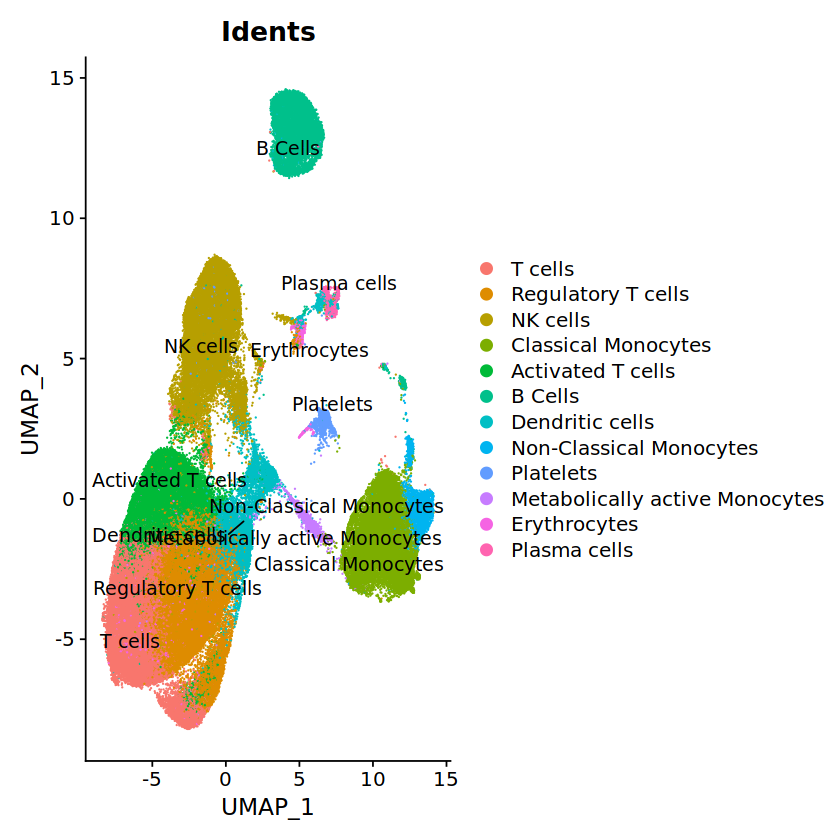

In [8]:
DimPlot(seurat_obj, group.by = "Idents", label = TRUE, repel = TRUE, raster = FALSE)

In [4]:
table(seurat_obj$Idents)


                       T cells             Regulatory T cells 
                         25739                          24362 
                      NK cells            Classical Monocytes 
                         19406                          16373 
             Activated T cells                        B Cells 
                         15664                           9065 
               Dendritic cells        Non-Classical Monocytes 
                          7762                           2618 
                     Platelets Metabolically active Monocytes 
                          1432                           1158 
                  Erythrocytes                   Plasma cells 
                          1054                            636 

In [5]:
# re-naming clusters based on Azimuth
new_cluster_names <- c("T cells" = "Naive CD4+ T",
                       "Regulatory T cells" = "Memory CD4+ T", 
                       "NK cells" = "Cytotoxic CD8+ T",
                       "Classical Monocytes" = "Classical Monocytes",
                       "Activated T cells" = "CD4+ T CD69+",
                       "B Cells" = "B cells",
                       "Dendritic cells" = "CD4+ T PRKCQ+", 
                       "Non-Classical Monocytes" = "Non-classical Mono CD16+",
                       "Platelets" = "Platelets",
                       "Metabolically active Monocytes" = "Non-classical Mono NR4A1+",
                       "Erythrocytes" = "RBC",
                       "Plasma cells" = "Plasmablasts"
                      )

seurat_obj <- RenameIdents(seurat_obj, new_cluster_names)

In [12]:
table(seurat_obj$CSclassification)


    HF     KS 
 18363 106906 

In [8]:
table(seurat_obj$Patient)


  HF10   HF11   HF12   HF13   HF14   HF15   HF16   HF17    HF2    HF3    HF4 
  1893    821    992    755   1288   1094   1779    217    951   2420      2 
   HF5    HF6    HF7    HF9  KS1.1 KS10.1 KS10.2 KS11.1 KS11.2 KS11.3 KS12.1 
  2629   1298   1043   1181   1586   1089    201    224    751    460    520 
KS12.2 KS12.3 KS13.1 KS13.2 KS13.3 KS14.1 KS14.2 KS15.1 KS16.1 KS16.2 KS16.3 
  1073    655   2475   1298   2342   1159   2221   1770   1990   1582   2104 
KS17.1 KS17.2 KS17.3 KS18.1 KS19.1 KS19.2 KS19.3  KS2.1  KS2.2  KS2.3 KS20.1 
  1844   1441   1792    511    313   1677   1572   1020    767    465    542 
KS20.2 KS21.1 KS21.2 KS22.1 KS22.2 KS23.1 KS23.2 KS24.1 KS24.2 KS24.3 KS25.1 
  2291    336   1587   1691   1947   3221   1226    217    141    950   1087 
KS25.2 KS25.3 KS26.1 KS26.2 KS26.3 KS27.1 KS27.2 KS29.1 KS29.2 KS29.3  KS3.1 
  2210    705   1788   1060   1353   1638    940   1294   1886   1369   1042 
 KS3.2 KS31.1 KS31.2 KS31.3 KS32.1 KS33.1 KS33.2 KS33.3 KS34.1 

In [7]:
seurat_obj$New_Idents = Idents(seurat_obj)

In [18]:
library(dplyr)
library(tidyr)

# Extract metadata from your Seurat object
metadata <- seurat_obj@meta.data

# Create summary table with counts per cluster per patient
cell_counts <- metadata %>%
  group_by(Patient, CSclassification, New_Idents) %>%
  summarise(cell_count = n(), .groups = 'drop') %>%
  arrange(Patient, New_Idents)

# Write to CSV - use row.names with a PERIOD
write.csv(cell_counts, "cell_counts_per_patient_cluster.csv", row.names = FALSE)

# Optional: Create a wide format pivot table (clusters as columns)
cell_counts_wide <- cell_counts %>%
  pivot_wider(
    names_from = New_Idents,
    values_from = cell_count,
    values_fill = 0
  )

write.csv(cell_counts_wide, "cell_counts_wide_format.csv", row.names = FALSE)

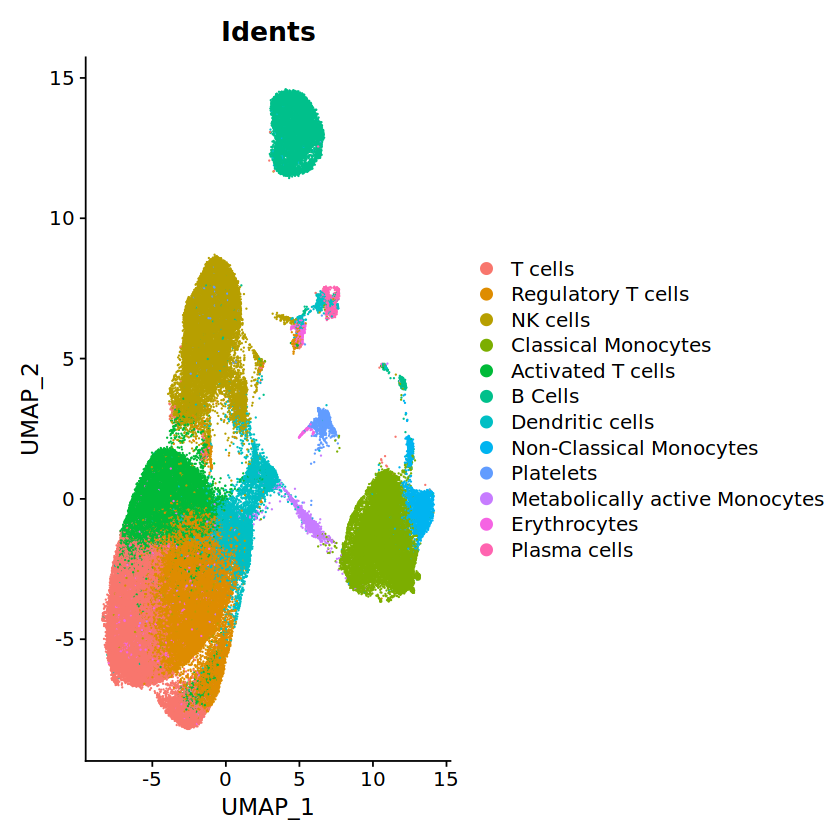

In [10]:
DimPlot(seurat_obj, group.by = "Idents", label = FALSE, repel = TRUE, raster = FALSE)

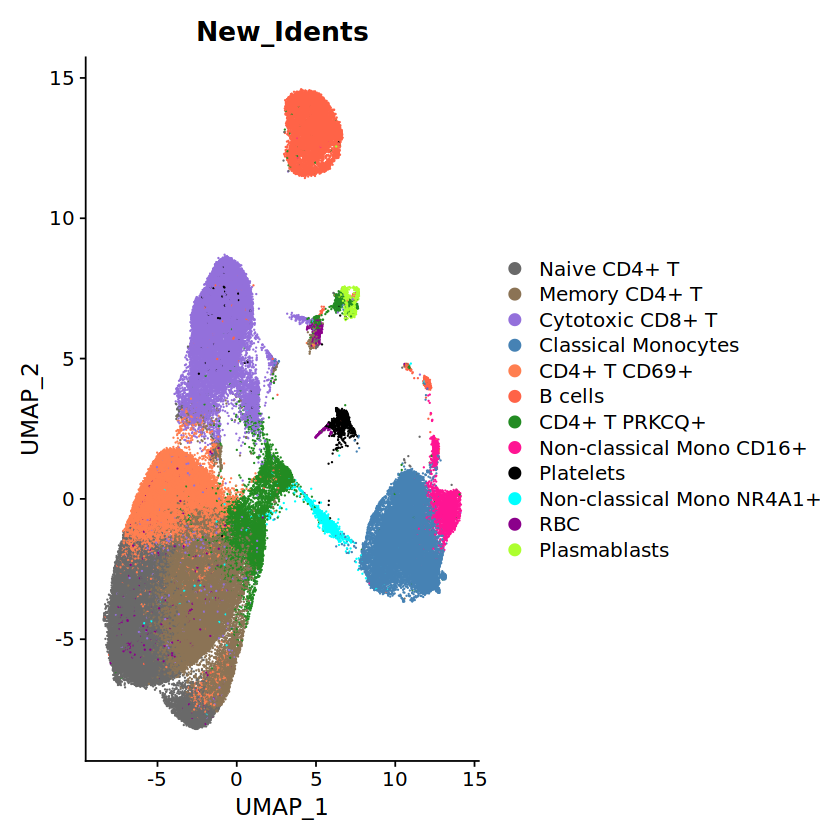

In [11]:
# Update cluster_colors with the new shorter names
cluster_colors <- c(
  "Naive CD4+ T" = "#696969",
  "Memory CD4+ T" = "#8B7355",
  "Cytotoxic CD8+ T" = "#9370DB",
  "Classical Monocytes" = "#4682B4",
  "CD4+ T CD69+" = "#FF7F50",
  "B cells" = "#FF6347",
  "CD4+ T PRKCQ+" = "#228B22",
  "Non-classical Mono CD16+" = "#FF1493",
  "Platelets" = "#000000",
  "Non-classical Mono NR4A1+" = "#00FFFF",
  "RBC" = "#8B008B",
  "Plasmablasts" = "#ADFF2F"
)

# Plot with shorter names
DimPlot(seurat_obj, 
        group.by = "New_Idents", 
        label = FALSE, 
        repel = TRUE, 
        raster = FALSE,
        cols = cluster_colors)

In [57]:
# Save the DimPlot as PDF
pdf("DimPlot_custom_colors_mofa_colors_final.pdf", width = 10, height = 8)
DimPlot(seurat_obj, 
        group.by = "New_Idents", 
        label = FALSE, 
        repel = TRUE, 
        raster = FALSE,
        cols = cluster_colors)
dev.off()

png 
  2

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


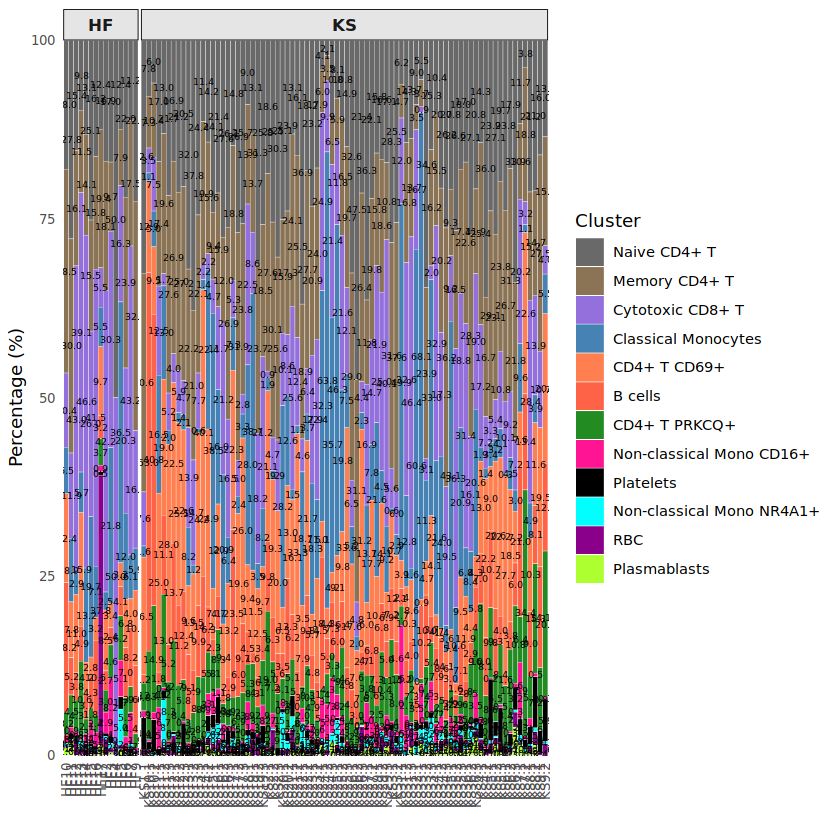

In [15]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(tidyr)

# Define your cluster colors
cluster_colors <- c(
  "Naive CD4+ T" = "#696969",
  "Memory CD4+ T" = "#8B7355",
  "Cytotoxic CD8+ T" = "#9370DB",
  "Classical Monocytes" = "#4682B4",
  "CD4+ T CD69+" = "#FF7F50",
  "B cells" = "#FF6347",
  "CD4+ T PRKCQ+" = "#228B22",
  "Non-classical Mono CD16+" = "#FF1493",
  "Platelets" = "#000000",
  "Non-classical Mono NR4A1+" = "#00FFFF",
  "RBC" = "#8B008B",
  "Plasmablasts" = "#ADFF2F"
)

# Extract metadata from your Seurat object
metadata <- seurat_obj@meta.data

# Calculate cluster proportions per patient
cluster_props <- metadata %>%
  group_by(Patient, CSclassification, New_Idents) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(Patient) %>%
  mutate(proportion = count / sum(count) * 100) %>%
  ungroup()

# Order patients by CSclassification for cleaner visualization
patient_order <- metadata %>%
  select(Patient, CSclassification) %>%
  distinct() %>%
  arrange(CSclassification, Patient)

cluster_props$Patient <- factor(cluster_props$Patient, 
                                levels = patient_order$Patient)

# Create the stacked bar plot
p <- ggplot(cluster_props, aes(x = Patient, y = proportion, fill = New_Idents)) +
  geom_bar(stat = "identity", width = 1, color = "white", size = 0.1) +
  geom_text(aes(label = sprintf("%.1f", proportion)), 
            position = position_stack(vjust = 0.5),
            size = 2, color = "black") +
  facet_grid(. ~ CSclassification, scales = "free_x", space = "free_x") +
  scale_fill_manual(values = cluster_colors) +  # Apply your colors
  scale_y_continuous(expand = c(0, 0)) +
  labs(x = "", y = "Percentage (%)", fill = "Cluster") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
    axis.text.y = element_text(size = 8),
    strip.text = element_text(size = 10, face = "bold"),
    strip.background = element_rect(fill = "gray90", color = "black"),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) + geom_text(aes(label = sprintf("%.1f", proportion),
                 color = ifelse(New_Idents %in% c("Platelets", "RBC"), "white", "black")), 
            position = position_stack(vjust = 0.5),
            size = 2) +
   scale_color_identity()

print(p)

# Optional: Save the plot
ggsave("cluster_composition_by_patient.pdf", p, width = 16, height = 8)

In [31]:
top_markers <- cluster_markers %>%
  group_by(cluster) %>%
  top_n(n = 10, wt = avg_log2FC)  # Select by highest log fold-change

# Extract unique gene names
genes_to_plot <- unique(top_markers$gene)

In [25]:
head(cluster_markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
LTB,0,1.1711896,0.733,0.404,0,T cells,LTB
SNHG29,0,1.1225356,0.713,0.389,0,T cells,SNHG29
GAS5,0,0.9176748,0.795,0.479,0,T cells,GAS5
LDHB,0,1.3324964,0.561,0.248,0,T cells,LDHB
HINT1,0,1.0235760,0.713,0.410,0,T cells,HINT1
TOMM7,0,0.8941190,0.846,0.560,0,T cells,TOMM7


In [32]:
head(top_markers)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
0,1.171190,0.733,0.404,0,T cells,LTB
0,1.122536,0.713,0.389,0,T cells,SNHG29
0,1.332496,0.561,0.248,0,T cells,LDHB
0,1.032707,0.502,0.264,0,T cells,PCED1B-AS1
0,1.030873,0.491,0.268,0,T cells,FXYD5
0,1.028980,0.992,0.796,0,T cells,RPS5


In [33]:
write.csv(cluster_markers, "cluster_markers.csv")
write.csv(top_markers, "top_markers.csv")

In [30]:
p = DotPlot(
  seurat_obj,
  features = genes_to_plot,
  cols = c("lightgrey", "blue"),  # Color gradient
  dot.scale = 8
) + 
  RotatedAxis()  #
ggsave("cluster_markers_dotplot.pdf", plot = p, width = 22, height = 8)

In [ ]:
# Azimuth run

In [1]:

library(SeuratData)
InstallData("pbmcref")

# Step 4: Verify installation
library(pbmcref.SeuratData)
data("pbmcref")

Warning message in data("pbmcref"):
“data set ‘pbmcref’ not found”


In [5]:
library(Azimuth)
library(Seurat)
library(SeuratData)
pbmc <- RunAzimuth(seurat_obj, reference = "pbmcref")

Loading required package: SeuratObject

Loading required package: sp

Warning message:
"package 'sp' was built under R version 4.3.3"

Attaching package: 'sp'


The following object is masked from 'package:ggraph':

    geometry



Attaching package: 'SeuratObject'


The following object is masked from 'package:backports':

    %||%


The following objects are masked from 'package:base':

    intersect, t



Attaching package: 'Seurat'


The following object is masked from 'package:backports':

    %||%


Warning message:
"Overwriting miscellanous data for model"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
detected inputs from HUMAN with id type Gene.name

reference rownames detected HUMAN with id type Gene.name

Normalizing query using reference SCT model

Warning message:
"118 features of the features specified were not pres

In [12]:
cluster_annotations <- pbmc@meta.data %>%
  group_by(seurat_clusters, predicted.celltype.l2) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(seurat_clusters) %>%
  slice_max(count, n = 1, with_ties = FALSE) %>%
  select(seurat_clusters, predicted.celltype.l2)

In [28]:
cluster_annotations <- pbmc@meta.data %>%
  group_by(Idents, predicted.celltype.l2) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Idents) %>%
  slice_max(count, n = 1, with_ties = FALSE) %>%
  select(Idents, predicted.celltype.l2)

In [5]:
library(Azimuth)
library(Seurat)
library(SeuratData)

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat



Attaching shinyBS

── Installed datasets ──────────────────────────────────────────────────────────────── SeuratData v0.2.2.9001 ──

✔ pbmcref 1.0.0                                         


────────────────────────────────────────────────────── Key ─────────────────────────────────────────────────────

✔ Dataset loaded successfully
❯ Dataset built with a newer version of Seurat than installed
❓ Unknown version of Seurat installed




In [6]:
pbmc = readRDS("pbmc_azimuth_annotated.Rds")

In [7]:
table(pbmc@meta.data$Idents)


                       T cells             Regulatory T cells 
                         25739                          24362 
                      NK cells            Classical Monocytes 
                         19406                          16373 
             Activated T cells                        B Cells 
                         15664                           9065 
               Dendritic cells        Non-Classical Monocytes 
                          7762                           2618 
                     Platelets Metabolically active Monocytes 
                          1432                           1158 
                  Erythrocytes                   Plasma cells 
                          1054                            636 

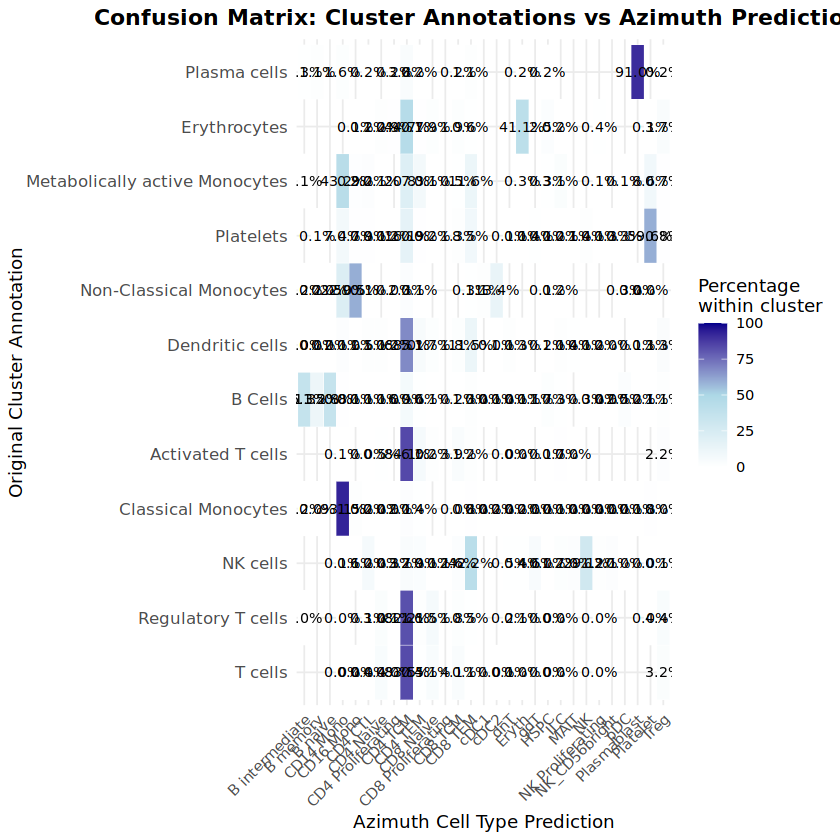

In [8]:
library(ggplot2)
library(dplyr)

# Create confusion matrix with counts
confusion_data <- pbmc@meta.data %>%
  group_by(Idents, predicted.celltype.l2) %>%
  summarise(count = n(), .groups = "drop")

# Calculate percentages within each cluster (row percentages)
confusion_pct <- confusion_data %>%
  group_by(Idents) %>%
  mutate(
    total = sum(count),
    percentage = (count / total) * 100
  ) %>%
  ungroup()

# Create the heatmap
p <- ggplot(confusion_pct, aes(x = predicted.celltype.l2, y = Idents, fill = percentage)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.1f%%", percentage)), size = 3) +
  scale_fill_gradient2(low = "white", mid = "lightblue", high = "darkblue", 
                       midpoint = 50, limits = c(0, 100),
                       name = "Percentage\nwithin cluster") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.text.y = element_text(size = 10),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  labs(
    title = "Confusion Matrix: Cluster Annotations vs Azimuth Predictions",
    x = "Azimuth Cell Type Prediction",
    y = "Original Cluster Annotation"
  )

# Display the plot
print(p)


In [9]:
ggsave("confusion_matrix_azimuth.pdf", p, width = 14, height = 8)
ggsave("confusion_matrix_azimuth.png", p, width = 14, height = 8, dpi = 300)

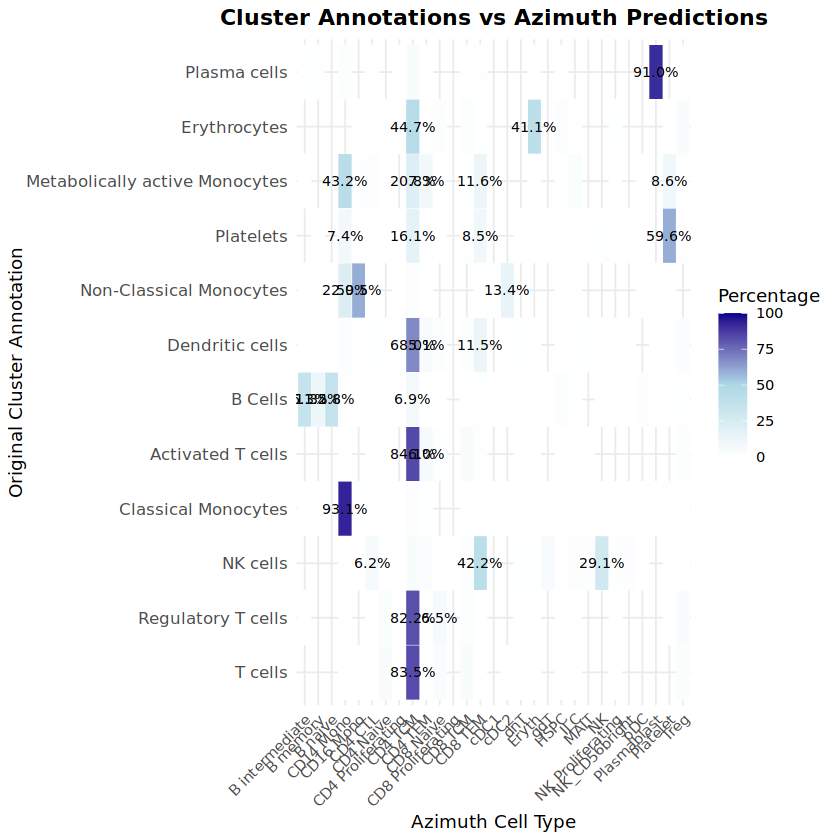

In [10]:
confusion_pct_filtered <- confusion_pct %>%
  filter(percentage > 5)

p2 <- ggplot(confusion_pct, aes(x = predicted.celltype.l2, y = Idents, fill = percentage)) +
  geom_tile(color = "white") +
  geom_text(data = confusion_pct_filtered, 
            aes(label = sprintf("%.1f%%", percentage)), size = 3) +
  scale_fill_gradient2(low = "white", mid = "lightblue", high = "darkblue", 
                       midpoint = 50, limits = c(0, 100),
                       name = "Percentage") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.text.y = element_text(size = 10),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  labs(
    title = "Cluster Annotations vs Azimuth Predictions",
    x = "Azimuth Cell Type",
    y = "Original Cluster Annotation"
  )

print(p2)
ggsave("confusion_matrix_clean.pdf", p2, width = 14, height = 8)

In [ ]:
# differential expression analysis HF vs KS_TP1

In [8]:
seurat_obj$PatientGroup <- seurat_obj$Patient

# Identify which cells belong to HF (all timepoints) or KS timepoint 1
seurat_obj$ComparisonGroup <- ifelse(
  grepl("^HF", seurat_obj$Patient), "HF",
  ifelse(grepl("\\.1$", seurat_obj$Patient), "KS_TP1", "Other")
)

# Check the distribution
table(seurat_obj$ComparisonGroup, seurat_obj$CSclassification)


        
            HF    KS
  HF     18363     0
  KS_TP1     0 46640
  Other      0 60266

In [9]:
table(seurat_obj$New_Idents, seurat_obj$ComparisonGroup)

                           
                               HF KS_TP1 Other
  Naive CD4+ T               3125   9234 13380
  Memory CD4+ T              3193   8152 13017
  Cytotoxic CD8+ T           5124   6248  8034
  Classical Monocytes        2592   8241  5540
  CD4+ T CD69+               1197   5214  9253
  B cells                    1233   3936  3896
  CD4+ T PRKCQ+               753   2696  4313
  Non-classical Mono CD16+    568   1281   769
  Platelets                   101    623   708
  Non-classical Mono NR4A1+   201    488   469
  RBC                         200    338   516
  Plasmablasts                 76    189   371

In [12]:
cell_types <- unique(seurat_obj$New_Idents)
cell_types <- cell_types[!is.na(cell_types)] 
cell_types

[1] Naive CD4+ T              Memory CD4+ T            
 [3] Classical Monocytes       B cells                  
 [5] Cytotoxic CD8+ T          Platelets                
 [7] CD4+ T CD69+              CD4+ T PRKCQ+            
 [9] Plasmablasts              Non-classical Mono CD16+ 
[11] Non-classical Mono NR4A1+ RBC                      
12 Levels: Naive CD4+ T Memory CD4+ T Cytotoxic CD8+ T ... Plasmablasts

In [22]:
library(ggplot2)
library(dplyr)
library(Seurat)
library(ggrepel)  # For non-overlapping labels

# Subset data
seurat_subset <- subset(seurat_obj, ComparisonGroup %in% c("HF", "KS_TP1"))

# CRITICAL: Prepare SCT data for FindMarkers
seurat_subset <- PrepSCTFindMarkers(seurat_subset)

# Set the identity to cluster classification
Idents(seurat_subset) <- "New_Idents"

# Create output directory
dir.create("DE_results_HF_vs_KS_TP1", showWarnings = FALSE)

# Perform DE analysis and create plots for each cluster
for (cluster in unique(seurat_subset$New_Idents)) {
  cat("Processing cluster:", cluster, "\n")
  
  # Subset to current cluster
  cluster_cells <- subset(seurat_subset, New_Idents == cluster)
  
  # Set identity to comparison group
  Idents(cluster_cells) <- "ComparisonGroup"
  
  # Check if both groups exist in this cluster
  if (length(unique(cluster_cells$ComparisonGroup)) < 2) {
    cat("  Skipping - only one group present\n")
    next
  }
  
  # Perform DE analysis: HF vs KS_TP1
  tryCatch({
    de_results <- FindMarkers(
      cluster_cells,
      ident.1 = "HF",
      ident.2 = "KS_TP1",
      test.use = "wilcox",
      min.pct = 0.1,
      logfc.threshold = 0.25,
      recorrect_umi = FALSE
    )
    
    # Add gene names and cluster info
    de_results$gene <- rownames(de_results)
    de_results$cluster <- cluster
    
    # Filter significant genes (p_val_adj < 0.05)
    sig_genes <- de_results[de_results$p_val_adj < 0.05, ]
    
    # Save significant results to CSV
    write.csv(
      sig_genes,
      file = paste0("DE_results_HF_vs_KS_TP1/", cluster, "_significant_genes.csv"),
      row.names = FALSE
    )
    
    # Also save all results (not just significant)
    write.csv(
      de_results,
      file = paste0("DE_results_HF_vs_KS_TP1/", cluster, "_all_genes.csv"),
      row.names = FALSE
    )
    
    # Create volcano plot
    # Color by direction and significance
    de_results$color_group <- ifelse(
      de_results$p_val_adj >= 0.05, "NS",
      ifelse(de_results$avg_log2FC > 0.5, "Up in HF",
             ifelse(de_results$avg_log2FC < -0.5, "Up in KS_TP1", "NS"))
    )
    
    # Select top genes to label (top 10 by p-value in each direction)
    # Top upregulated in HF
    top_hf <- de_results %>%
      filter(p_val_adj < 0.05, avg_log2FC > 0.5) %>%
      arrange(p_val_adj) %>%
      head(10)
    
    # Top upregulated in KS_TP1
    top_ks <- de_results %>%
      filter(p_val_adj < 0.05, avg_log2FC < -0.5) %>%
      arrange(p_val_adj) %>%
      head(10)
    
    # Combine top genes to label
    genes_to_label <- rbind(top_hf, top_ks)
    
    # Create volcano plot
    p <- ggplot(de_results, aes(x = avg_log2FC, y = -log10(p_val_adj), color = color_group)) +
      geom_point(alpha = 0.6, size = 2) +
      scale_color_manual(
        values = c("Up in HF" = "#d62728", "Up in KS_TP1" = "#1f77b4", "NS" = "grey70"),
        name = "Expression"
      ) +
      geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
      geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "black") +
      geom_text_repel(
        data = genes_to_label,
        aes(label = gene),
        size = 3,
        max.overlaps = 20,
        box.padding = 0.5,
        point.padding = 0.3,
        segment.color = "grey50",
        min.segment.length = 0
      ) +
      labs(
        title = paste0("Cluster ", cluster, ": HF vs KS (TP1)"),
        x = "Average log2 Fold Change",
        y = "-log10(Adjusted P-value)",
        subtitle = paste0("n_sig = ", nrow(sig_genes), " genes")
      ) +
      theme_bw() +
      theme(
        plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
        plot.subtitle = element_text(hjust = 0.5, size = 10),
        legend.position = "right"
      )
    
    # Save volcano plot
    ggsave(
      filename = paste0("DE_results_HF_vs_KS_TP1/", cluster, "_volcano.pdf"),
      plot = p,
      width = 10,
      height = 7
    )
    
    # Also save as PNG
    ggsave(
      filename = paste0("DE_results_HF_vs_KS_TP1/", cluster, "_volcano.png"),
      plot = p,
      width = 10,
      height = 7,
      dpi = 300
    )
    
    cat("  Completed:", nrow(sig_genes), "significant genes\n")
    
  }, error = function(e) {
    cat("  Error:", e$message, "\n")
  })
}

cat("\nAll results saved in 'DE_results_HF_vs_KS_TP1' directory\n")

Found 12 SCT models. Recorrecting SCT counts using minimum median counts: 1090



Processing cluster: Memory CD4+ T 
  Completed: 261 significant genes
Processing cluster: Classical Monocytes 
  Completed: 651 significant genes
Processing cluster: Naive CD4+ T 
  Completed: 143 significant genes
Processing cluster: B cells 
  Completed: 173 significant genes
Processing cluster: Cytotoxic CD8+ T 
  Completed: 301 significant genes
Processing cluster: CD4+ T CD69+ 
  Completed: 234 significant genes
Processing cluster: CD4+ T PRKCQ+ 
  Completed: 102 significant genes
Processing cluster: Non-classical Mono CD16+ 
  Completed: 202 significant genes
Processing cluster: Non-classical Mono NR4A1+ 
  Completed: 1 significant genes
Processing cluster: Plasmablasts 
  Completed: 1 significant genes
Processing cluster: RBC 
  Completed: 165 significant genes
Processing cluster: Platelets 
  Completed: 7 significant genes

All results saved in 'DE_results_HF_vs_KS_TP1' directory
